<a href="https://colab.research.google.com/github/kintaladhanalaxmi2007-ux/NATURAL-LANGUAGE-PROCESSING/blob/main/NLP_SENTIMENT_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**NLP CASE STUDY**

Natural Language Processing (NLP) is a branch of Artificial Intelligence that helps computers understand, interpret, and respond to human language (text or speech).

**Data Understanding & Exploration**

In [ ]:
import pandas as pd

Load dataset

In [ ]:
df=pd.read_csv("/content/IMDB Dataset.csv")
print(df)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
13554  I'm a huge lover of really bad B movies. And I...  negative
13555  Now I myself had previously seen a few episode...  positive
13556  This film started off really tense when a poor...  negative
13557  First off, this movie was a wild ride the whol...  positive
13558  well-made documentary about a sailing race, sa...  positive

[13559 rows x 2 columns]


Display the first 5 and last 5 rows

In [ ]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.tail(5)

,review,sentiment
13554,I'm a huge lover of really bad B movies. And I...,negative
13555,Now I myself had previously seen a few episode...,positive
13556,This film started off really tense when a poor...,negative
13557,"First off, this movie was a wild ride the whol...",positive
13558,"well-made documentary about a sailing race, sa...",positive


The total number of reviews present in the dataset

In [ ]:
df['review'].count()

np.int64(13559)

count of each sentiment

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,6840
positive,6719


Check dataset balance

In [ ]:
df['sentiment'].value_counts(normalize=True)*100  #normalize:convert counts into proportions (fractions)

,proportion
sentiment,
negative,50.446198
positive,49.553802


**EXPLANATION:**
Dataset is balanced because both positive and negative reviews are nearly equal around 50% each.

Check missing value

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


**Observations**


*   Equal distribution of positive and negative reviews

*   Dataset is balanced
*   No missing values found


*   List item



##Text Preprocessing

Import libraries

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



*   re → text cleaning (remove symbols, HTML)

*   nltk → NLP operations

*   word_tokenize → split text into words
*   stopwords → remove common words


*   WordNetLemmatizer → convert words to base form





**Download NLTK data**(natural language tool kit)

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**Initialize tools**

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



*  Stop_words : list of common words(is,the,end)
*  lemmatizer :tool to reduce words to root form



**Function : clean_text()**

In [ ]:
def clean_text(text):
    return(text)


**convert text to lower case**

In [ ]:
df['review_lower']=df['review'].str.lower()
print(df[['review','review_lower']].head())


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        review_lower  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production. <br /><br />the...  
2  i thought this was a wonderful way to spend ti...  
3  basically there's a family where a little boy ...  
4  petter mattei's "love in the time of money" is...  


**NOTE**
The review text is converted into lowercase using str.lower() to maintain uniformity in text preprocessing

**Remove HTML tags**

In [ ]:
def remove_html(text):
  return re.sub(r'<.*?>', '', text)
df['review_clean']=df['review_lower'].apply(remove_html)
print(df[['review_lower','review_clean']].head())

                                        review_lower  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production. <br /><br />the...   
2  i thought this was a wonderful way to spend ti...   
3  basically there's a family where a little boy ...   
4  petter mattei's "love in the time of money" is...   

                                        review_clean  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production. the filming tec...  
2  i thought this was a wonderful way to spend ti...  
3  basically there's a family where a little boy ...  
4  petter mattei's "love in the time of money" is...  


**Note** : removes HTML elements like <,br,>,<,p> which are not useful

**Remove numbers and special characters**

In [ ]:
def remove_special(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)
df['review_clean2'] = df['review_clean'].apply(remove_special)
print(df[['review_clean', 'review_clean2']].head())

                                        review_clean  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production. the filming tec...   
2  i thought this was a wonderful way to spend ti...   
3  basically there's a family where a little boy ...   
4  petter mattei's "love in the time of money" is...   

                                       review_clean2  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


**Note** : keeps only alphabets and removes digits/symbols

**Remove extra whitespace**

In [ ]:
def remove_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()
df['review_clean3'] = df['review_clean2'].apply(remove_whitespace)
print(df[['review_clean2', 'review_clean3']].head())

                                       review_clean2  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                       review_clean3  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


**Explanation**


*   \s+ → matches multiple spaces

*   ' ' → replaces with single space
*   .strip() → removes spaces from start & end

**Tokenize the cleaned text into individual words**

In [ ]:
nltk.download('punkt_tab')
def tokenize_text(text):
    return word_tokenize(text)
df['tokens'] = df['review_clean3'].apply(tokenize_text)

print(df[['review_clean3', 'tokens']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                       review_clean3  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                              tokens  
0  [one, of, the, other, reviewers, has, mentione...  
1  [a, wonderful, little, production, the, filmin...  
2  [i, thought, this, was, a, wonderful, way, to,...  
3  [basically, theres, a, family, where, a, littl...  
4  [petter, matteis, love, in, the, time, of, mon...  


**Explanation**


*   word_tokenize() spilts sentence into words
*   converts text into a list of tokens

Tokenize is the process of splitting text into individual words (tokens) for further NLP processing





**Stopwords Removal**

In [ ]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]
df['tokens_clean'] = df['tokens'].apply(remove_stopwords)
print(df[['tokens', 'tokens_clean']].head())

                                              tokens  \
0  [one, of, the, other, reviewers, has, mentione...   
1  [a, wonderful, little, production, the, filmin...   
2  [i, thought, this, was, a, wonderful, way, to,...   
3  [basically, theres, a, family, where, a, littl...   
4  [petter, matteis, love, in, the, time, of, mon...   

                                        tokens_clean  
0  [one, reviewers, mentioned, watching, oz, epis...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, theres, family, little, boy, jake,...  
4  [petter, matteis, love, time, money, visually,...  


**Explanation**:


*   stopwords.words('english') → list of common words
*   Removes words like: is, the, and, was, in
*   Keeps only meaningful words

Stopwords are removed to eliminate common words that do not contribute to the meaning of the text, improving model performance.”

**Lemmatization**

In [ ]:
lemmatizer = WordNetLemmatizer()
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]
df['tokens_lemma'] = df['tokens_clean'].apply(lemmatize_tokens)
print(df[['tokens_clean', 'tokens_lemma']].head())

                                        tokens_clean  \
0  [one, reviewers, mentioned, watching, oz, epis...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, theres, family, little, boy, jake,...   
4  [petter, matteis, love, time, money, visually,...   

                                        tokens_lemma  
0  [one, reviewer, mentioned, watching, oz, episo...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, there, family, little, boy, jake, ...  
4  [petter, matteis, love, time, money, visually,...  


**Explanation:**


*   WordNetLemmatizer() → converts words to root form
*   Makes words more meaningful for analysis

Lemmatization converts words into their base or dictionary form, improving the quality of text data for NLP models

**Join the toknes**

In [ ]:
def join_words(tokens):
    return " ".join(tokens)
df['final_clean_text'] = df['tokens_lemma'].apply(join_words)
print(df[['tokens_lemma', 'final_clean_text']].head())

                                        tokens_lemma  \
0  [one, reviewer, mentioned, watching, oz, episo...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, there, family, little, boy, jake, ...   
4  [petter, matteis, love, time, money, visually,...   

                                    final_clean_text  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


Lowercase → Clean → Tokenize → Remove Stopwords → Lemmatize → Join

**Apply the function to the entire review column**

In [ ]:
df[['review','final_clean_text']].head(10)

,review,final_clean_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...
5,"Probably my all-time favorite movie, a story o...",probably alltime favorite movie story selfless...
6,I sure would like to see a resurrection of a u...,sure would like see resurrection dated seahunt...
7,"This show was an amazing, fresh & innovative i...",show amazing fresh innovative idea first aired...
8,Encouraged by the positive comments about this...,encouraged positive comment film looking forwa...
9,If you like original gut wrenching laughter yo...,like original gut wrenching laughter like movi...


**one review before and after preprocessing**

In [ ]:
df['clean_review']=df['review'].apply(clean_text)

In [ ]:
print("Before:\n", df['review'][0])
print("\nAfter:\n", df['clean_review'][0])

Before:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

**Explanation**

The clean_text() function is applied to the entire review column using .apply(). A sample review is displayed before and after preprocessing to show the transformation.

**The target variable (sentiment) into numerical format using Label Encoding.**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

print(df[['sentiment', 'sentiment_encoded']].head())

  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


**Explanation**

Convert text labels into numbers
*   positive__1
*   negative__0

label encoding is use to convert categorical sentiment values into numerical format for machine learning model



**Bag of Words (CountVectorizer) on the processed review text**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=500)
X_bow = cv.fit_transform(df['clean_review'])
print(X_bow)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1026463 stored elements and shape (13559, 500)>
  Coords	Values
  (0, 299)	1
  (0, 292)	7
  (0, 402)	16
  (0, 303)	2
  (0, 182)	1
  (0, 401)	4
  (0, 10)	1
  (0, 460)	2
  (0, 219)	2
  (0, 122)	2
  (0, 497)	3
  (0, 242)	3
  (0, 39)	2
  (0, 408)	1
  (0, 29)	2
  (0, 344)	2
  (0, 31)	4
  (0, 412)	3
  (0, 212)	9
  (0, 466)	2
  (0, 477)	5
  (0, 262)	4
  (0, 59)	6
  (0, 150)	2
  (0, 409)	1
  :	:
  (13558, 191)	1
  (13558, 283)	1
  (13558, 30)	2
  (13558, 61)	1
  (13558, 459)	1
  (13558, 463)	1
  (13558, 175)	1
  (13558, 194)	1
  (13558, 467)	1
  (13558, 249)	1
  (13558, 144)	2
  (13558, 317)	1
  (13558, 485)	2
  (13558, 280)	1
  (13558, 389)	1
  (13558, 393)	1
  (13558, 252)	1
  (13558, 101)	1
  (13558, 352)	1
  (13558, 83)	1
  (13558, 131)	1
  (13558, 384)	1
  (13558, 57)	1
  (13558, 397)	1
  (13558, 217)	1


**Explanation**
*   convert text into words count vectors
*   max_features=500__limits number of words

bag of words converts text into numerical vectors based on word frequency



**The shape of the Bag of Words feature matrix**

In [ ]:
print(X_bow.shape)

(13559, 500)


**Explanation**
*   output : rows,columns
*   rows__number of reviews
*  columns__number of features words





**TF-IDF Vectorizer on the processed review text**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_review'])
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1594182 stored elements and shape (13559, 5000)>
  Coords	Values
  (0, 3112)	0.0195513147446799
  (0, 3087)	0.09210360213069045
  (0, 4440)	0.20218005857634838
  (0, 3141)	0.05758253159829825
  (0, 3689)	0.07058449568631939
  (0, 2058)	0.024062395037475322
  (0, 2813)	0.059803796422200566
  (0, 4438)	0.0606831748113752
  (0, 154)	0.03116837378307572
  (0, 4828)	0.07192302336910725
  (0, 2442)	0.04640647412937657
  (0, 3167)	0.48732538392639624
  (0, 1525)	0.10699920131205136
  (0, 4990)	0.06023651709648942
  (0, 2636)	0.12389176520334555
  (0, 424)	0.03920322890811867
  (0, 2167)	0.07707373523902546
  (0, 4455)	0.023009625125645427
  (0, 296)	0.0402151709418633
  (0, 3705)	0.07961353962030147
  (0, 322)	0.07186804905855948
  (0, 4466)	0.041023088939911
  (0, 2367)	0.12477709701186332
  (0, 1570)	0.054073700885498496
  (0, 4868)	0.04814802104951381
  :	:
  (13558, 1330)	0.07487239725651378
  (13558, 3828)	0.10908724903590065


**Explanation**
*   same concept as bow
*   uaually same shape if same features used

The TF-IDF matrix shape represent numbers of reviews and extracted features



**The shape of the TF-IDF feature matrix**

In [ ]:
print(X_tfidf.shape)

(13559, 5000)


**Train test spilt**

**The dataset into training and testing sets using a 75:25 ratio**

In [ ]:
from sklearn.model_selection import train_test_split
X = X_tfidf
y = df['sentiment_encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1192182 stored elements and shape (10169, 5000)>
  Coords	Values
  (0, 3112)	0.08179898009264322
  (0, 3087)	0.12844798104432928
  (0, 4440)	0.123357921212833
  (0, 4438)	0.10578618951326474
  (0, 2442)	0.03235930936146348
  (0, 4990)	0.028002013772879746
  (0, 424)	0.027336474834726312
  (0, 296)	0.028042103649242995
  (0, 322)	0.02505685334127326
  (0, 4466)	0.11442186469659678
  (0, 2367)	0.15467959337552864
  (0, 4868)	0.06714738568329169
  (0, 2781)	0.0779215333542172
  (0, 74)	0.09813155017221413
  (0, 4817)	0.050469697877676446
  (0, 235)	0.10854087936714031
  (0, 2263)	0.05917915568277134
  (0, 3043)	0.02648897435246708
  (0, 3128)	0.09843785030743661
  (0, 3023)	0.036855476076715576
  (0, 4516)	0.09244233074849198
  (0, 2374)	0.09717075426823774
  (0, 3110)	0.10167496351981747
  (0, 196)	0.028930813666976186
  (0, 4054)	0.061228565405022584
  :	:
  (10168, 1861)	0.05179067613972678
  (10168, 4340)	0.0561141849151453

**Explanation**
*   X__input features
*   Y__target variable(sentiment)
*  test_size=0.25__25%data for testing
*   random_state=42__ ensure same spilt every time
*  the dataset is spilt into training 75% and testing 25% sets using train_test spilt to evault model performance on unseen data





**The shape of X_train, X_test, y_train, and y_test**

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10169, 5000)
X_test shape: (3390, 5000)
y_train shape: (10169,)
y_test shape: (3390,)



*   Train data__used to learn model
*   Test data__used to check performance


**Model Building – Classical NLP Models**

**Train a Naive Bayes classifier using Bag of Words features**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_bow, df['sentiment_encoded'])

MultinomialNB()

**Explanation**
*  MultinomialNB()___naive bayes model for text data
*   fit__trains is model
*   Naive bayes clasifier is trained using bag of words features to classify text sentiment








**Predict the sentiment for test data**

In [ ]:
y_pred = nb_model.predict(X_test)
print(y_pred)

[1 0 0 ... 1 0 1]


predict sentiment for unseen test data

**The model using accuracy score**

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8542772861356932


**Explanation**

*   measures correct predictions
*   Accuracy score measure the proportion of correctly predict instance



**Confusion matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[1471  244]
 [ 250 1425]]


**Explanation**
*   True positive
*   True negative
*   Flase positive
*   Flase negative

Confusion matrix shows the performance of the model by comparing actual and predicted values




**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1715
           1       0.85      0.85      0.85      1675

    accuracy                           0.85      3390
   macro avg       0.85      0.85      0.85      3390
weighted avg       0.85      0.85      0.85      3390




**Explanation**
*   Precision:out of predicted positives
*   Recall:out of actual positives
*   F1_score:balance between precision & recall
*   Class0__negative
*   Class1__positive
*   Higher F1_score better model






**Repeat steps 23–25 using TF-IDF features**

In [ ]:
nb_model_tfidf = MultinomialNB()
nb_model_tfidf.fit(X_train, y_train)
y_pred_tfidf = nb_model_tfidf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(confusion_matrix(y_test, y_pred_tfidf))
print(classification_report(y_test, y_pred_tfidf))

Accuracy: 0.8542772861356932
[[1471  244]
 [ 250 1425]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1715
           1       0.85      0.85      0.85      1675

    accuracy                           0.85      3390
   macro avg       0.85      0.85      0.85      3390
weighted avg       0.85      0.85      0.85      3390



**Additional Models (Functionalized Approach)**

**Write a reusable function to train and evaluate classification models**

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Model:", model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print("-"*50)

**Explanation**

A reusable function is created to train and evaluate multiple models efficiently using classification metrics

**Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
evaluate_model(DecisionTreeClassifier(), X_train, X_test, y_train, y_test)

Model: DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.70      0.69      0.69      1715
           1       0.69      0.69      0.69      1675

    accuracy                           0.69      3390
   macro avg       0.69      0.69      0.69      3390
weighted avg       0.69      0.69      0.69      3390

--------------------------------------------------


**K-Nearest Neighbors Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
evaluate_model(KNeighborsClassifier(), X_train, X_test, y_train, y_test)

Model: KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.67      0.74      0.71      1715
           1       0.71      0.63      0.67      1675

    accuracy                           0.69      3390
   macro avg       0.69      0.69      0.69      3390
weighted avg       0.69      0.69      0.69      3390

--------------------------------------------------


**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
evaluate_model(RandomForestClassifier(), X_train, X_test, y_train, y_test)

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1715
           1       0.85      0.83      0.84      1675

    accuracy                           0.84      3390
   macro avg       0.84      0.84      0.84      3390
weighted avg       0.84      0.84      0.84      3390

--------------------------------------------------


**Word Embeddings & Visualization**

**Generate word cloud for positive review**

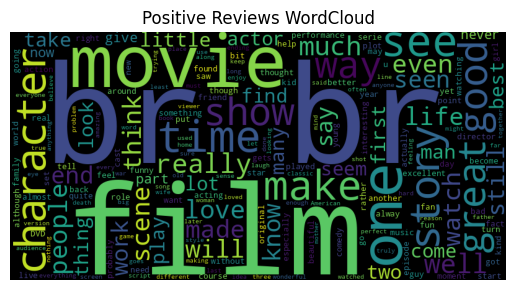

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
positive_text = " ".join(df[df['sentiment_encoded'] == 1]['clean_review'])
wc_positive = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wc_positive)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

**Generate word cloud for negative review**

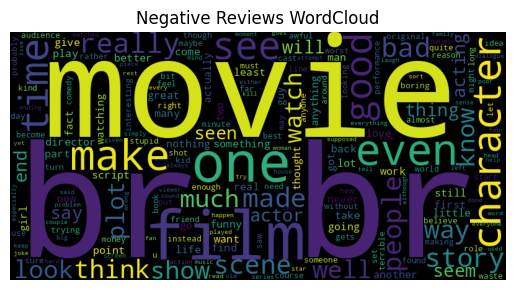

In [ ]:
negative_text = " ".join(df[df['sentiment_encoded'] == 0]['clean_review'])
wc_negative = WordCloud(width=800, height=400).generate(negative_text)
plt.imshow(wc_negative)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

word cloud visualizes the most frequent words in positive and negative reviews helping identify common pattern

**Identify most frequency words**

In [ ]:
from collections import Counter
words = positive_text.split()
print(Counter(words).most_common(10))

[('the', 78052), ('and', 44155), ('a', 41681), ('of', 39878), ('to', 34317), ('is', 29162), ('in', 23903), ('that', 16784), ('I', 16486), ('it', 14320)]


Most frequency words are identified using counter to analyze commonly used terms in review

**Train word2vec model**

In [ ]:
pip install gensim

In [ ]:
from gensim.models import Word2Vec
tokenized_reviews = [text.split() for text in df['clean_review']]
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2)
print(w2v_model)

Word2Vec<vocab=74235, vector_size=100, alpha=0.025>


word2vec model id trained to generate vector representations of words based on their context

**word vectors for at least 3 sentiment-related words**

In [ ]:
print(w2v_model.wv['good'])
print(w2v_model.wv['bad'])
print(w2v_model.wv['movie'])

[-1.5168215e+00 -2.8330786e+00 -9.3757826e-01 -6.8794042e-01
 -2.3071451e+00 -1.6216153e+00  1.2728277e+00  3.5647950e+00
 -3.2528298e+00  1.4543712e+00  1.8022144e+00 -4.3881759e-01
  1.2057593e+00  7.3437792e-01 -4.9941695e-01  1.1504267e+00
 -3.6844850e+00 -3.1291444e+00  1.6346822e+00  8.3109486e-01
  1.2199184e+00  2.6042062e-01 -6.1724186e-01 -4.8243707e-01
  3.1502584e-01 -1.4790473e+00  2.0383356e+00 -3.2245505e-01
  4.3525955e-01 -1.9876461e+00 -8.0608052e-01  1.0483837e+00
  3.1969552e+00 -1.6453692e-01 -1.1531562e+00 -3.6561564e-02
  1.6999800e+00  1.3743284e-01 -3.2135686e-01  7.1698231e-01
  9.9086207e-01 -1.0249271e+00  1.4037262e+00 -3.1422186e-03
  1.8469472e-01  7.9900318e-01  1.0014131e+00  5.9088391e-01
  1.6300623e-01 -1.1543168e-01  9.5619965e-01 -2.0274968e+00
  1.1771821e+00 -4.4748423e-01 -6.1780643e-01 -2.1077061e-01
  3.3037438e+00  2.6298954e+00  1.7318347e+00  5.7650417e-01
  9.8490423e-01 -6.3379198e-01  1.1478436e+00 -1.5504009e-01
 -2.2193921e+00  2.98170

word vectors are numerical representations of words capturing their semantic meaning